<a href="https://colab.research.google.com/github/Laere11/Laere11/blob/Batteries/image_data_extraction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

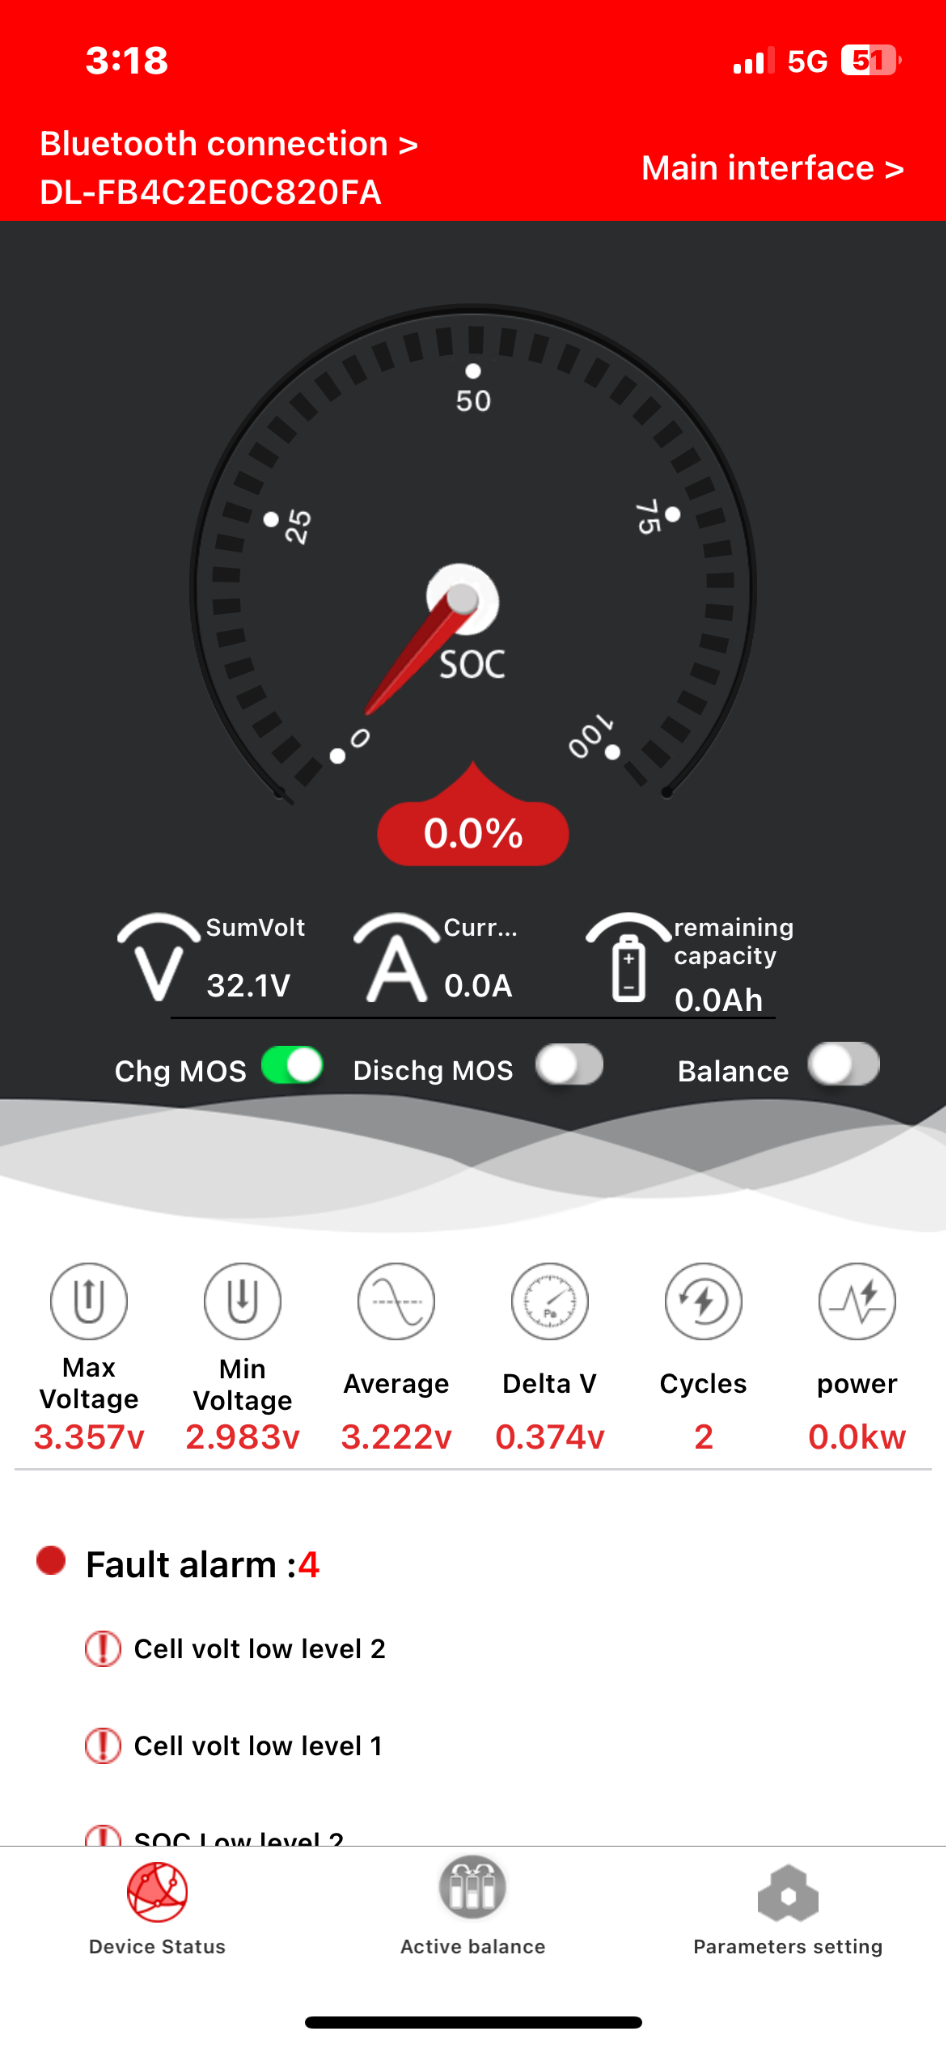

Code to extract data from the Smart BMS bluetooth app screen capture, used on the Beach Cruiser ebike

Below is an example of Python code you can run in Google Colab that implements the described process for a Category 2 image. This script uses OpenCV for preprocessing, pytesseract for OCR, and regular expressions to extract the key data fields.

Before running the code, ensure you have uploaded a Category 2 image (e.g., category2.png) to your Colab environment or that you provide its path.

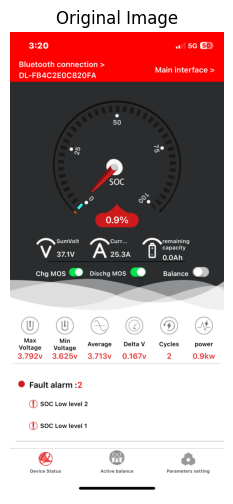

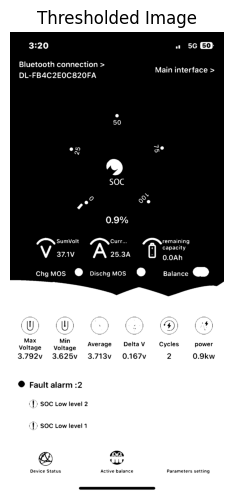

OCR Extracted Text:
 3:20 a 56 &
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
\
y Pia Se
0.9%
Tr Sumvolt — A ACurr... me Vea)
V4 A capacity
37.1V 25.3A J 0.0Ah
Chgmos @ pischgmos @ ren
Voltage Voltage Average Delta V Cycles power
3.792v 3.625v 3.713v 0.167v 2 0.9kw
@ Fault alarm :2
iT) SOC Low level 2
iT) SOC Low level 1
&) it
uy
Device Status Active balance Parameters setting
Fe


Extracted Data Fields:
Timestamp: 3:20
SOC (%): 0.9
SumVolt (V): 37.1
Cur (A): 25.3
Remaining Capacity (Ah): 0.0
Max Voltage (V): 3.792
Min Voltage (V): 3.625
Average Voltage (V): 3.713
Delta V (V): 0.167


In [2]:
# Install necessary packages (if not already installed)
!apt-get install -qq tesseract-ocr
!pip install -q pytesseract opencv-python

import cv2
import pytesseract
import re
import matplotlib.pyplot as plt

# Function to display image (optional)
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Function to preprocess the image
def preprocess_image(image_path):
    image = cv2.imread(image_path)
    if image is None:
        raise FileNotFoundError(f"Image not found: {image_path}")
    # Convert to grayscale
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply median blur to reduce noise
    gray = cv2.medianBlur(gray, 3)
    # Use Otsu's thresholding to get a binary image
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return image, gray, thresh

# Function to run OCR and return the extracted text
def extract_text(image):
    # Use Tesseract with configuration (oem 3, psm 6)
    custom_config = r'--oem 3 --psm 6'
    ocr_text = pytesseract.image_to_string(image, config=custom_config)
    return ocr_text

# Improved function to extract a value using a regex pattern with IGNORECASE and DOTALL if needed
def extract_value(pattern, text, default="N/A"):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return default

# Main function to process a Category 2 image and extract data fields
def process_category2_image(image_path):
    # Preprocess image
    original, gray, thresh = preprocess_image(image_path)

    # (Optional) Display original and thresholded images
    display_image(original, "Original Image")
    display_image(thresh, "Thresholded Image")

    # Extract text using OCR
    ocr_text = extract_text(thresh)
    print("OCR Extracted Text:\n", ocr_text)

    # Extract the timestamp (first occurrence of a time like 3:20)
    timestamp = extract_value(r"(\d{1,2}:\d{2})", ocr_text, default="Unknown")

    # Extract SOC (look for "SOC" and then capture the first number followed by a %)
    soc = extract_value(r"SOC[\s\S]*?([0-9.]+)%", ocr_text)

    # Extract SumVolt, Cur, and Rem Cap using a pattern:
    # This pattern searches for a sequence like "37.1V 25.3A ...0.0Ah" (allowing non-digit characters in between)
    sc_pattern = r"([0-9.]+)\s*V\s+([0-9.]+)\s*A\s+\D*([0-9.]+)\s*Ah"
    sc_match = re.search(sc_pattern, ocr_text, re.IGNORECASE)
    if sc_match:
        sumvolt = sc_match.group(1).strip()
        cur = sc_match.group(2).strip()
        rem_cap = sc_match.group(3).strip()
    else:
        sumvolt = cur = rem_cap = "N/A"

    # Extract the voltage details: Max, Min, Average, Delta
    # Look for four numbers ending with "v" in a row (this corresponds to the line "3.792v 3.625v 3.713v 0.167v")
    volt_pattern = r"([0-9.]+)\s*v\s+([0-9.]+)\s*v\s+([0-9.]+)\s*v\s+([0-9.]+)\s*v"
    volt_match = re.search(volt_pattern, ocr_text, re.IGNORECASE)
    if volt_match:
        max_voltage = volt_match.group(1).strip()
        min_voltage = volt_match.group(2).strip()
        avg_voltage = volt_match.group(3).strip()
        delta_v = volt_match.group(4).strip()
    else:
        max_voltage = min_voltage = avg_voltage = delta_v = "N/A"

    # Organize extracted values into a dictionary
    data = {
        "Timestamp": timestamp,
        "SOC (%)": soc,
        "SumVolt (V)": sumvolt,
        "Cur (A)": cur,
        "Remaining Capacity (Ah)": rem_cap,
        "Max Voltage (V)": max_voltage,
        "Min Voltage (V)": min_voltage,
        "Average Voltage (V)": avg_voltage,
        "Delta V (V)": delta_v
    }

    return data

# Replace 'category2.png' with the name/path of your uploaded Category 2 image.
image_path = "/content/IMG_4982.PNG"
extracted_data = process_category2_image(image_path)

print("\nExtracted Data Fields:")
for key, value in extracted_data.items():
    print(f"{key}: {value}")


Prompts user for the images that need to be processed.

In [3]:
# Install necessary packages
!apt-get install -qq tesseract-ocr
!pip install -q pytesseract opencv-python pandas

import cv2
import pytesseract
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Optional: Function to display an image (for debugging)
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Preprocess the image: convert to grayscale, reduce noise, and threshold.
def preprocess_image_from_array(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply median blur to reduce noise
    gray = cv2.medianBlur(gray, 3)
    # Use Otsu's thresholding to convert to a binary image
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return gray, thresh

# Extract text from an image using Tesseract OCR.
def extract_text(image):
    # Use Tesseract configuration: OEM 3 (LSTM), PSM 6 (assume a uniform block of text)
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(image, config=custom_config)
    return text

# Improved helper to extract values using a regex pattern.
def extract_value(pattern, text, default="N/A"):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return default

# Process a single Category 2 image provided as a numpy array.
def process_category2_image_array(image, filename=None):
    # Preprocess the image
    gray, thresh = preprocess_image_from_array(image)

    # Optionally display the image and threshold result
    # display_image(image, "Original: " + (filename if filename else ""))
    # display_image(thresh, "Thresholded: " + (filename if filename else ""))

    # Extract OCR text from the thresholded image.
    ocr_text = extract_text(thresh)
    print(f"OCR Extracted Text for {filename if filename else 'Image'}:\n{ocr_text}\n")

    # Extract the timestamp: look for a pattern like "3:20"
    timestamp = extract_value(r"(\d{1,2}:\d{2})", ocr_text, default="Unknown")

    # Extract SOC: look for "SOC" and then a number ending in '%'
    soc = extract_value(r"SOC[\s\S]*?([0-9.]+)%", ocr_text)

    # Extract SumVolt, Cur, and Remaining Capacity:
    # Pattern example: "37.1V 25.3A ...0.0Ah"
    sc_pattern = r"([0-9.]+)\s*V\s+([0-9.]+)\s*A\s+\D*([0-9.]+)\s*Ah"
    sc_match = re.search(sc_pattern, ocr_text, re.IGNORECASE)
    if sc_match:
        sumvolt = sc_match.group(1).strip()
        cur = sc_match.group(2).strip()
        rem_cap = sc_match.group(3).strip()
    else:
        sumvolt = cur = rem_cap = "N/A"

    # Extract voltage details: look for a sequence like "3.792v 3.625v 3.713v 0.167v"
    volt_pattern = r"([0-9.]+)\s*v\s+([0-9.]+)\s*v\s+([0-9.]+)\s*v\s+([0-9.]+)\s*v"
    volt_match = re.search(volt_pattern, ocr_text, re.IGNORECASE)
    if volt_match:
        max_voltage = volt_match.group(1).strip()
        min_voltage = volt_match.group(2).strip()
        avg_voltage = volt_match.group(3).strip()
        delta_v = volt_match.group(4).strip()
    else:
        max_voltage = min_voltage = avg_voltage = delta_v = "N/A"

    # Compile the extracted information into a dictionary.
    data = {
        "Filename": filename if filename else "Unknown",
        "Timestamp": timestamp,
        "SOC (%)": soc,
        "SumVolt (V)": sumvolt,
        "Cur (A)": cur,
        "Remaining Capacity (Ah)": rem_cap,
        "Max Voltage (V)": max_voltage,
        "Min Voltage (V)": min_voltage,
        "Average Voltage (V)": avg_voltage,
        "Delta V (V)": delta_v
    }

    return data

# --- Main Routine: Upload and Process Multiple Images ---

# Prompt the user to upload multiple images.
print("Please upload your Category 2 images:")
uploaded_files = files.upload()

# List to store extracted data dictionaries.
data_list = []

# Process each uploaded image.
for filename, filecontent in uploaded_files.items():
    # Convert the uploaded bytes into a NumPy array.
    nparr = np.frombuffer(filecontent, np.uint8)
    # Decode the image (color image in BGR format)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Process the image and extract data.
    image_data = process_category2_image_array(img, filename)
    data_list.append(image_data)

# Create a Pandas DataFrame from the collected data.
df = pd.DataFrame(data_list)

# Sort the table by Timestamp if possible (ignores 'Unknown' values).
def convert_timestamp(ts):
    try:
        # Convert timestamp string (e.g., "3:20") to minutes since midnight.
        parts = ts.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return float('inf')

df['Time_Sort'] = df['Timestamp'].apply(convert_timestamp)
df.sort_values('Time_Sort', inplace=True)
df.drop(columns=['Time_Sort'], inplace=True)

# Display the final table.
print("\nFinal Extracted Data Table:")
print(df.to_string(index=False))


Please upload your Category 2 images:


Saving IMG_4982.PNG to IMG_4982 (1).PNG
Saving IMG_4983.PNG to IMG_4983 (1).PNG
Saving IMG_4985.PNG to IMG_4985 (1).PNG
Saving IMG_4987.PNG to IMG_4987 (1).PNG
Saving IMG_4990.PNG to IMG_4990 (1).PNG
Saving IMG_4992.PNG to IMG_4992 (1).PNG
Saving IMG_4994.PNG to IMG_4994 (1).PNG
Saving IMG_4996.PNG to IMG_4996 (1).PNG
Saving IMG_4998.PNG to IMG_4998 (1).PNG
Saving IMG_5001.PNG to IMG_5001 (1).PNG
OCR Extracted Text for IMG_4982 (1).PNG:
3:20 a 56 &
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
\
y Pia Se
0.9%
Tr Sumvolt — A ACurr... me Vea)
V4 A capacity
37.1V 25.3A J 0.0Ah
Chgmos @ pischgmos @ ren
Voltage Voltage Average Delta V Cycles power
3.792v 3.625v 3.713v 0.167v 2 0.9kw
@ Fault alarm :2
iT) SOC Low level 2
iT) SOC Low level 1
&) it
uy
Device Status Active balance Parameters setting
Fe


OCR Extracted Text for IMG_4983 (1).PNG:
Ere al 56 &)
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
z \
cA °° SP
5.2%
Tr Sumvolt — A 

updated to reduce N/A and Uknowns

In [4]:
# Install necessary packages (if not already installed)
!apt-get install -qq tesseract-ocr
!pip install -q pytesseract opencv-python pandas

import cv2
import pytesseract
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Optional: Function to display an image (for debugging)
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Preprocess an image given as a numpy array:
def preprocess_image_from_array(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply a median blur to reduce noise
    gray = cv2.medianBlur(gray, 3)
    # Use Otsu's thresholding to obtain a binary image
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return gray, thresh

# Extract text from an image using Tesseract OCR.
def extract_text(image):
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(image, config=custom_config)
    return text

# Improved helper to extract values using a regex pattern with DOTALL to capture newlines.
def extract_value(pattern, text, default="N/A"):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return default

# Process a single Category 2 image (provided as a numpy array) and extract the fields.
def process_category2_image_array(image, filename=None):
    # Preprocess the image.
    gray, thresh = preprocess_image_from_array(image)

    # (Optional) Display images for debugging.
    # display_image(image, "Original: " + (filename if filename else ""))
    # display_image(thresh, "Thresholded: " + (filename if filename else ""))

    # Extract OCR text.
    ocr_text = extract_text(thresh)
    print(f"OCR Extracted Text for {filename if filename else 'Image'}:\n{ocr_text}\n")

    # Extract the timestamp (look for a pattern like "3:20").
    timestamp = extract_value(r"(\d{1,2}:\d{2})", ocr_text, default="Unknown")

    # Extract SOC: use a more flexible pattern to capture text after "SOC"
    soc = extract_value(r"SOC.*?([0-9.]+)%", ocr_text)

    # For SumVolt, Cur, and Remaining Capacity, allow any characters in between.
    sc_pattern = r"([0-9.]+)\s*V.*?([0-9.]+)\s*A.*?([0-9.]+)\s*Ah"
    sc_match = re.search(sc_pattern, ocr_text, re.IGNORECASE | re.DOTALL)
    if sc_match:
        sumvolt = sc_match.group(1).strip()
        cur = sc_match.group(2).strip()
        rem_cap = sc_match.group(3).strip()
    else:
        sumvolt = cur = rem_cap = "N/A"

    # Extract voltage details (Max, Min, Average, Delta).
    # We look for four numbers with a trailing 'v' or 'V'. Sometimes extra characters may be present, so allow flexibility.
    volt_pattern = r"([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV]"
    volt_match = re.search(volt_pattern, ocr_text, re.IGNORECASE | re.DOTALL)
    if volt_match:
        max_voltage = volt_match.group(1).strip()
        min_voltage = volt_match.group(2).strip()
        avg_voltage = volt_match.group(3).strip()
        delta_v = volt_match.group(4).strip()
    else:
        max_voltage = min_voltage = avg_voltage = delta_v = "N/A"

    # Organize the extracted data into a dictionary.
    data = {
        "Filename": filename if filename else "Unknown",
        "Timestamp": timestamp,
        "SOC (%)": soc,
        "SumVolt (V)": sumvolt,
        "Cur (A)": cur,
        "Remaining Capacity (Ah)": rem_cap,
        "Max Voltage (V)": max_voltage,
        "Min Voltage (V)": min_voltage,
        "Average Voltage (V)": avg_voltage,
        "Delta V (V)": delta_v
    }

    return data

# --- Main Routine: Upload and Process Multiple Images ---

print("Please upload your Category 2 images:")
uploaded_files = files.upload()

data_list = []

for filename, filecontent in uploaded_files.items():
    nparr = np.frombuffer(filecontent, np.uint8)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    image_data = process_category2_image_array(img, filename)
    data_list.append(image_data)

# Create a Pandas DataFrame.
df = pd.DataFrame(data_list)

# Attempt to sort by Timestamp (if the timestamp is numeric). Timestamps that are "Unknown" will be placed at the end.
def convert_timestamp(ts):
    try:
        parts = ts.split(':')
        return int(parts[0]) * 60 + int(parts[1])
    except:
        return float('inf')

df['Time_Sort'] = df['Timestamp'].apply(convert_timestamp)
df.sort_values('Time_Sort', inplace=True)
df.drop(columns=['Time_Sort'], inplace=True)

# Display the final table.
print("\nFinal Extracted Data Table:")
print(df.to_string(index=False))


Please upload your Category 2 images:


Saving IMG_4982.PNG to IMG_4982 (2).PNG
Saving IMG_4983.PNG to IMG_4983 (2).PNG
Saving IMG_4985.PNG to IMG_4985 (2).PNG
Saving IMG_4987.PNG to IMG_4987 (2).PNG
Saving IMG_4990.PNG to IMG_4990 (2).PNG
Saving IMG_4992.PNG to IMG_4992 (2).PNG
Saving IMG_4994.PNG to IMG_4994 (2).PNG
Saving IMG_4996.PNG to IMG_4996 (2).PNG
Saving IMG_4998.PNG to IMG_4998 (2).PNG
Saving IMG_5001.PNG to IMG_5001 (2).PNG
OCR Extracted Text for IMG_4982 (2).PNG:
3:20 a 56 &
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
\
y Pia Se
0.9%
Tr Sumvolt — A ACurr... me Vea)
V4 A capacity
37.1V 25.3A J 0.0Ah
Chgmos @ pischgmos @ ren
Voltage Voltage Average Delta V Cycles power
3.792v 3.625v 3.713v 0.167v 2 0.9kw
@ Fault alarm :2
iT) SOC Low level 2
iT) SOC Low level 1
&) it
uy
Device Status Active balance Parameters setting
Fe


OCR Extracted Text for IMG_4983 (2).PNG:
Ere al 56 &)
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
z \
cA °° SP
5.2%
Tr Sumvolt — A 

elimated reporting on the table label values that it could not read

In [5]:
# Install necessary packages (if not already installed)
!apt-get install -qq tesseract-ocr
!pip install -q pytesseract opencv-python pandas

import cv2
import pytesseract
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Optional: Function to display an image (for debugging)
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Preprocess an image given as a numpy array.
def preprocess_image_from_array(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply a median blur to reduce noise.
    gray = cv2.medianBlur(gray, 3)
    # Use Otsu's thresholding to obtain a binary image.
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return gray, thresh

# Extract text from an image using Tesseract OCR.
def extract_text(image):
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(image, config=custom_config)
    return text

# Helper function to extract a value using a regex pattern.
def extract_value(pattern, text, default="N/A"):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return default

# Process a single image to extract the voltage values.
def process_voltage_image_array(image, filename=None):
    # Preprocess the image.
    gray, thresh = preprocess_image_from_array(image)

    # (Optional) Display the images for debugging.
    # display_image(image, "Original: " + (filename if filename else ""))
    # display_image(thresh, "Thresholded: " + (filename if filename else ""))

    # Extract OCR text.
    ocr_text = extract_text(thresh)
    print(f"OCR Extracted Text for {filename if filename else 'Image'}:\n{ocr_text}\n")

    # Use a regex pattern to extract four voltage numbers.
    # The pattern looks for four numbers with a trailing "v" (or "V") possibly separated by extra text.
    volt_pattern = r"([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV]"
    volt_match = re.search(volt_pattern, ocr_text, re.IGNORECASE | re.DOTALL)
    if volt_match:
        max_voltage = volt_match.group(1).strip()
        min_voltage = volt_match.group(2).strip()
        avg_voltage = volt_match.group(3).strip()
        delta_v   = volt_match.group(4).strip()
    else:
        max_voltage = min_voltage = avg_voltage = delta_v = "N/A"

    data = {
        "Filename": filename if filename else "Unknown",
        "Max Voltage (V)": max_voltage,
        "Min Voltage (V)": min_voltage,
        "Average Voltage (V)": avg_voltage,
        "Delta V (V)": delta_v
    }

    return data

# --- Main Routine: Upload and Process Multiple Images ---

print("Please upload your images:")
uploaded_files = files.upload()

data_list = []

# Process each uploaded image.
for filename, filecontent in uploaded_files.items():
    # Convert the uploaded bytes into a NumPy array.
    nparr = np.frombuffer(filecontent, np.uint8)
    # Decode the image (in color)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Process the image to extract the voltage information.
    image_data = process_voltage_image_array(img, filename)
    data_list.append(image_data)

# Create a Pandas DataFrame from the extracted data.
df = pd.DataFrame(data_list)

# Display the final table.
print("\nFinal Extracted Data Table:")
print(df.to_string(index=False))


Please upload your images:


Saving IMG_4982.PNG to IMG_4982 (3).PNG
Saving IMG_4983.PNG to IMG_4983 (3).PNG
Saving IMG_4985.PNG to IMG_4985 (3).PNG
Saving IMG_4987.PNG to IMG_4987 (3).PNG
Saving IMG_4990.PNG to IMG_4990 (3).PNG
Saving IMG_4992.PNG to IMG_4992 (3).PNG
Saving IMG_4994.PNG to IMG_4994 (3).PNG
Saving IMG_4996.PNG to IMG_4996 (3).PNG
Saving IMG_4998.PNG to IMG_4998 (3).PNG
Saving IMG_5001.PNG to IMG_5001 (3).PNG
OCR Extracted Text for IMG_4982 (3).PNG:
3:20 a 56 &
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
\
y Pia Se
0.9%
Tr Sumvolt — A ACurr... me Vea)
V4 A capacity
37.1V 25.3A J 0.0Ah
Chgmos @ pischgmos @ ren
Voltage Voltage Average Delta V Cycles power
3.792v 3.625v 3.713v 0.167v 2 0.9kw
@ Fault alarm :2
iT) SOC Low level 2
iT) SOC Low level 1
&) it
uy
Device Status Active balance Parameters setting
Fe


OCR Extracted Text for IMG_4983 (3).PNG:
Ere al 56 &)
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
z \
cA °° SP
5.2%
Tr Sumvolt — A 

Below is an explanation of how we can use robust Z‑scores (based on the median and median absolute deviation, or MAD) to flag outlier voltage values, followed by a Python snippet that analyzes the provided data and suggests a threshold.

Reasoning and Analysis
In our data table the “Max Voltage (V)” and “Delta V (V)” columns show two distinct groups. For example:

Max Voltage (V): Most values are in the range of about 3.9–4.2 V—but some values are around 37–39 V, which are clearly off.

Delta V (V): Most values are around 0.05–0.07 V, but a few are in the 3.7–3.9 V range.

Because a few extreme values can skew the mean and standard deviation, we use robust statistics. In this approach, we compute the median and MAD (median absolute deviation) for each column. The robust Z‑score for each value is given by:

𝑍
robust
=
∣
𝑥
−
median
∣
MAD
Z
robust
​
 =
MAD
∣x−median∣
​

A common rule of thumb is to flag values with robust Z‑scores above 3 (or sometimes 3.5) as outliers. In our data, if you compute these robust Z‑scores:

Max Voltage (V): The “good” values cluster around ~4.0 V, and the erroneous ones (e.g., 37.1, 38.6, 39.2, 39.7) yield extremely high Z‑scores (in the hundreds) when compared to a median near 4.0.

Delta V (V): Valid readings are around 0.05–0.07 V. Erroneous ones (≈3.7–3.9 V) will have robust Z‑scores far exceeding 3.

Average Voltage (V): Values that are much lower (e.g., 3.625) or much higher (e.g., 4.109) than the typical ~3.91–3.94 range would also be flagged if their robust Z‑score is greater than 3.

Min Voltage (V): This column appears consistent (ranging roughly from 3.79 to 4.09), so it might not need outlier flagging; if applied, a threshold around 3 would typically work.

Thus, a robust Z‑score threshold of about 3 is a reasonable starting point to flag outlier values for each of the voltage columns.

In [6]:
import pandas as pd
import numpy as np

# Create the DataFrame from the provided data.
data = {
    "Filename": [
        "IMG_4982 (3).PNG", "IMG_4983 (3).PNG", "IMG_4985 (3).PNG",
        "IMG_4987 (3).PNG", "IMG_4990 (3).PNG", "IMG_4992 (3).PNG",
        "IMG_4994 (3).PNG", "IMG_4996 (3).PNG", "IMG_4998 (3).PNG",
        "IMG_5001 (3).PNG"
    ],
    "Max Voltage (V)": [37.1, 38.6, 3.934, 3.940, 3.943, 39.2, 3.968, 39.7, 4.063, 4.142],
    "Min Voltage (V)": [3.792, 3.890, 3.880, 3.884, 3.884, 3.946, 3.900, 4.004, 4.000, 4.088],
    "Average Voltage (V)": [3.625, 3.842, 3.908, 3.914, 3.919, 3.887, 3.936, 3.937, 4.028, 4.109],
    "Delta V (V)": [3.713, 3.867, 0.054, 0.056, 0.059, 3.923, 0.068, 3.971, 0.063, 0.054]
}

df = pd.DataFrame(data)

# Function to compute robust Z-scores using median and MAD.
def robust_z_score(series):
    median = series.median()
    mad = np.median(np.abs(series - median))
    # Avoid division by zero
    if mad == 0:
        return pd.Series([0]*len(series), index=series.index)
    return np.abs(series - median) / mad

# Columns to analyze.
columns = ["Max Voltage (V)", "Min Voltage (V)", "Average Voltage (V)", "Delta V (V)"]

# Compute robust Z-scores for each column.
z_scores = {}
for col in columns:
    z_scores[col] = robust_z_score(df[col])
    df[f"robust_z_{col}"] = z_scores[col]

# Set the threshold for outliers.
threshold = 3

print("Robust Z-Scores for Each Column:")
print(df[[f"robust_z_{col}" for col in columns]])

# Identify and print outliers.
print("\nOutliers (threshold = {}):".format(threshold))
for col in columns:
    outliers = df[df[f"robust_z_{col}"] > threshold][["Filename", col, f"robust_z_{col}"]]
    if not outliers.empty:
        print(f"\nColumn: {col}")
        print(outliers.to_string(index=False))
    else:
        print(f"\nColumn: {col} - No outliers found based on threshold.")



Robust Z-Scores for Each Column:
   robust_z_Max Voltage (V)  robust_z_Min Voltage (V)  \
0                199.380665                  3.121212   
1                208.444109                  0.151515   
2                  1.018127                  0.454545   
3                  0.981873                  0.333333   
4                  0.963746                  0.333333   
5                212.069486                  1.545455   
6                  0.812689                  0.151515   
7                215.090634                  3.303030   
8                  0.238671                  3.181818   
9                  0.238671                  5.848485   

   robust_z_Average Voltage (V)  robust_z_Delta V (V)  
0                         11.66            317.173913  
1                          2.98            330.565217  
2                          0.34              1.000000  
3                          0.10              0.826087  
4                          0.10              0.565217  
5  

It did not elminate the rows as expected for the images which had a Z-score of more or less than 3 in any of the voltage columns.  Please update the code to fix the issue.


ChatGPT said:
Reasoned for 13 seconds
Below is the updated code. In this version, after processing the images and building the DataFrame, we first convert the voltage columns to numeric (dropping rows with NaN in those columns), then compute standard Z‑scores, and finally filter out any rows where any voltage column has an absolute Z‑score greater than 3.

In [10]:
# Install necessary packages (if not already installed)
!apt-get install -qq tesseract-ocr
!pip install -q pytesseract opencv-python pandas

import cv2
import pytesseract
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import files

# Optional: Function to display an image (for debugging)
def display_image(image, title="Image"):
    plt.figure(figsize=(8, 6))
    plt.imshow(cv2.cvtColor(image, cv2.COLOR_BGR2RGB))
    plt.title(title)
    plt.axis("off")
    plt.show()

# Preprocess an image given as a numpy array.
def preprocess_image_from_array(image):
    gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)
    # Apply a median blur to reduce noise.
    gray = cv2.medianBlur(gray, 3)
    # Use Otsu's thresholding to obtain a binary image.
    _, thresh = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return gray, thresh

# Extract text from an image using Tesseract OCR.
def extract_text(image):
    custom_config = r'--oem 3 --psm 6'
    text = pytesseract.image_to_string(image, config=custom_config)
    return text

# Helper function to extract a value using a regex pattern.
def extract_value(pattern, text, default="N/A"):
    match = re.search(pattern, text, re.IGNORECASE | re.DOTALL)
    if match:
        return match.group(1).strip()
    return default

# Process a single image to extract the voltage values.
def process_voltage_image_array(image, filename=None):
    # Preprocess the image.
    gray, thresh = preprocess_image_from_array(image)

    # (Optional) Display the images for debugging.
    # display_image(image, "Original: " + (filename if filename else ""))
    # display_image(thresh, "Thresholded: " + (filename if filename else ""))

    # Extract OCR text.
    ocr_text = extract_text(thresh)
    print(f"OCR Extracted Text for {filename if filename else 'Image'}:\n{ocr_text}\n")

    # Use a regex pattern to extract four voltage numbers.
    # The pattern looks for four numbers with a trailing "v" (or "V") possibly separated by extra text.
    volt_pattern = r"([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV].*?([0-9.]+)\s*[vV]"
    volt_match = re.search(volt_pattern, ocr_text, re.IGNORECASE | re.DOTALL)
    if volt_match:
        max_voltage = volt_match.group(1).strip()
        min_voltage = volt_match.group(2).strip()
        avg_voltage = volt_match.group(3).strip()
        delta_v   = volt_match.group(4).strip()
    else:
        max_voltage = min_voltage = avg_voltage = delta_v = "N/A"

    data = {
        "Filename": filename if filename else "Unknown",
        "Max Voltage (V)": max_voltage,
        "Min Voltage (V)": min_voltage,
        "Average Voltage (V)": avg_voltage,
        "Delta V (V)": delta_v
    }

    return data

# --- Main Routine: Upload and Process Multiple Images ---

print("Please upload your images:")
uploaded_files = files.upload()

data_list = []

# Process each uploaded image.
for filename, filecontent in uploaded_files.items():
    # Convert the uploaded bytes into a NumPy array.
    nparr = np.frombuffer(filecontent, np.uint8)
    # Decode the image (in color)
    img = cv2.imdecode(nparr, cv2.IMREAD_COLOR)

    # Process the image to extract the voltage information.
    image_data = process_voltage_image_array(img, filename)
    data_list.append(image_data)

# Create a Pandas DataFrame from the extracted data.
df = pd.DataFrame(data_list)

# Convert the voltage columns to numeric (errors become NaN)
voltage_columns = ["Max Voltage (V)", "Min Voltage (V)", "Average Voltage (V)", "Delta V (V)"]
for col in voltage_columns:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows that have any NaN values in voltage columns.
df = df.dropna(subset=voltage_columns)

# Define a function to compute robust Z-scores for a Series.
def robust_z_score(series):
    median = series.median()
    mad = np.median(np.abs(series - median))
    if mad == 0:
        return pd.Series([0]*len(series), index=series.index)
    return (series - median).abs() / mad

# Compute robust Z-scores for each voltage column.
robust_z = pd.DataFrame()
for col in voltage_columns:
    robust_z[col] = robust_z_score(df[col])

# Create a mask that keeps only rows where every voltage column's robust Z-score is <= 3.
mask = (robust_z <= 3).all(axis=1)

# Filter the DataFrame.
df_filtered = df[mask].reset_index(drop=True)

# Display the final filtered table.
print("\nFinal Extracted Data Table (filtered):")
print(df_filtered.to_string(index=False))


Please upload your images:


Saving IMG_4982.PNG to IMG_4982 (6).PNG
Saving IMG_4983.PNG to IMG_4983 (6).PNG
Saving IMG_4985.PNG to IMG_4985 (6).PNG
Saving IMG_4987.PNG to IMG_4987 (6).PNG
Saving IMG_4990.PNG to IMG_4990 (6).PNG
Saving IMG_4992.PNG to IMG_4992 (6).PNG
Saving IMG_4994.PNG to IMG_4994 (6).PNG
Saving IMG_4996.PNG to IMG_4996 (6).PNG
Saving IMG_4998.PNG to IMG_4998 (6).PNG
Saving IMG_5001.PNG to IMG_5001 (6).PNG
OCR Extracted Text for IMG_4982 (6).PNG:
3:20 a 56 &
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
\
y Pia Se
0.9%
Tr Sumvolt — A ACurr... me Vea)
V4 A capacity
37.1V 25.3A J 0.0Ah
Chgmos @ pischgmos @ ren
Voltage Voltage Average Delta V Cycles power
3.792v 3.625v 3.713v 0.167v 2 0.9kw
@ Fault alarm :2
iT) SOC Low level 2
iT) SOC Low level 1
&) it
uy
Device Status Active balance Parameters setting
Fe


OCR Extracted Text for IMG_4983 (6).PNG:
Ere al 56 &)
Bluetooth connection > Main interface >
DL-FB4C2E0C820FA

e
tol 0]
a me
SOC
z \
cA °° SP
5.2%
Tr Sumvolt — A 

Explanation
Processing Images:
Each uploaded image is processed as before, with OCR extracting the voltage values and building a DataFrame.

Data Conversion:
The voltage columns are converted to numeric values. Any non-numeric values become NaN, and those rows are dropped from further analysis.

Z-Score Calculation:
The code computes the standard Z‑score for each voltage column:

𝑍
=
value
−
mean
std
Z=
std
value−mean
​

Filtering:
A row is kept only if every voltage column's absolute Z‑score is less than or equal to 3. Any row with a voltage value that falls outside the range (|Z| > 3) is removed.

Output:
The final filtered DataFrame is printed, containing only the rows where all voltage values are within the acceptable Z‑score range.

Run this updated code in Google Colab. It should now correctly filter out rows with any voltage column value having a Z‑score beyond ±3.